# Análisis de la representación de los streamlines en coordenadas polares

## Funciones auxiliares

In [6]:
import numpy as np 

def process_single_streamline(streamline, global_com, r_min, r_max, epsilon=1e-6):
    centered_streamline = streamline - global_com

    r = np.linalg.norm(centered_streamline, axis=1)
    r_normalized = (r - r_min) / (r_max - r_min + epsilon)

    theta = np.arccos(np.clip(centered_streamline[:, 2] / (r + epsilon), -1, 1))
    theta_cos = np.cos(theta)
    theta_sin = np.sin(theta)

    phi = np.arctan2(centered_streamline[:, 1], centered_streamline[:, 0])
    phi_cos = np.cos(phi)
    phi_sin = np.sin(phi)

    return np.stack(
        (r_normalized, theta_cos, theta_sin, phi_cos, phi_sin),
        axis=1
    )

In [2]:
def add_local_noise(streamline, noise_std=0.05):
    noise = np.random.normal(scale=noise_std, size=streamline.shape)
    return streamline + noise

In [17]:
def rotate_z(points, angle_rad):
    R = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad), 0],
        [np.sin(angle_rad),  np.cos(angle_rad), 0],
        [0, 0, 1]
    ])
    return points @ R.T

def rotate_x(points, angle_rad):
    R = np.array([
        [1, 0, 0],
        [0, np.cos(angle_rad), -np.sin(angle_rad)],
        [0, np.sin(angle_rad),  np.cos(angle_rad)]
    ])
    return points @ R.T

def rotate_y(points, angle_rad):
    R = np.array([
        [ np.cos(angle_rad), 0, np.sin(angle_rad)],
        [0, 1, 0],
        [-np.sin(angle_rad), 0, np.cos(angle_rad)]
    ])
    return points @ R.T

In [16]:
def mean_l2(a, b):
    return np.mean(np.linalg.norm(a - b, axis=1))


def feature_wise_l2(feat_a, feat_b):
    """
    Devuelve L2 medio por grupo de features:
    r, theta, phi
    """
    diff = feat_a - feat_b

    r_diff = np.mean(np.abs(diff[:, 0]))  # r_normalized

    theta_diff = np.mean(
        np.linalg.norm(diff[:, 1:3], axis=1)  # cosθ, sinθ
    )

    phi_diff = np.mean(
        np.linalg.norm(diff[:, 3:5], axis=1)  # cosφ, sinφ
    )

    return r_diff, theta_diff, phi_diff

## Datos sintéticos

In [7]:
np.random.seed(0)

# Streamline original (N puntos 3D)
streamline = np.random.randn(50, 3)

# Centro de masa
global_com = np.array([0.5, -0.2, 1.0])

r_min = 0.0
r_max = 5.0

## Traslation analysis

In [8]:
translation = np.array([10.0, -7.0, 3.0])
streamline_translated = streamline + translation
global_com_translated = global_com + translation

# ---------- Representación XYZ ----------
xyz_original = streamline
xyz_translated = streamline_translated

# ---------- Representación esférica (tu método) ----------
feat_original = process_single_streamline(
    streamline, global_com, r_min, r_max
)

feat_translated = process_single_streamline(
    streamline_translated, global_com_translated, r_min, r_max
)

xyz_diff = mean_l2(xyz_original, xyz_translated)
feat_diff = mean_l2(feat_original, feat_translated)

print("Cambio medio traslación L2 usando (x,y,z):", xyz_diff)
print("Cambio medio traslación L2 usando tu representación:", feat_diff)


Cambio medio traslación L2 usando (x,y,z): 12.569805089976535
Cambio medio traslación L2 usando tu representación: 4.328185307313737e-16


## Rotation analysis

In [9]:
angle = np.deg2rad(30)  # 30 grados
streamline_rot = rotate_z(streamline, angle)
global_com_rot = rotate_z(global_com[None, :], angle)[0]

# ---------- Features ----------
xyz_diff = np.mean(
    np.linalg.norm(streamline - streamline_rot, axis=1)
)

feat_orig = process_single_streamline(streamline, global_com, r_min, r_max)
feat_rot = process_single_streamline(streamline_rot, global_com_rot, r_min, r_max)

feat_diff = np.mean(
    np.linalg.norm(feat_orig - feat_rot, axis=1)
)

print("Cambio medio rotación L2 (x,y,z):", xyz_diff)
print("Cambio medio rotación L2 (tu representación):", feat_diff)

Cambio medio rotación L2 (x,y,z): 0.6982212642685164
Cambio medio rotación L2 (tu representación): 0.5176380902050414


## Curvature analysis

In [10]:
streamline_noisy = add_local_noise(streamline, noise_std=0.03)

# ---------- Comparación XYZ ----------
xyz_diff = np.mean(
    np.linalg.norm(streamline - streamline_noisy, axis=1)
)

# ---------- Comparación features ----------
feat_orig = process_single_streamline(streamline, global_com, r_min, r_max)
feat_noisy = process_single_streamline(streamline_noisy, global_com, r_min, r_max)

feat_diff = np.mean(
    np.linalg.norm(feat_orig - feat_noisy, axis=1)
)

print("Cambio medio curvatura L2 (x,y,z):", xyz_diff)
print("Cambio medio curvatura L2 (tu representación):", feat_diff)


Cambio medio curvatura L2 (x,y,z): 0.046901898895360825
Cambio medio curvatura L2 (tu representación): 0.03175164440907979


## Rotation analysis (individual features)

In [11]:
feat_orig = process_single_streamline(streamline, global_com, r_min, r_max)
feat_rot = process_single_streamline(streamline_rot, global_com_rot, r_min, r_max)

r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)

print("ROTACIÓN")
print("Cambio r:", r_d)
print("Cambio theta:", theta_d)
print("Cambio phi:", phi_d)


ROTACIÓN
Cambio r: 1.0547118733938987e-17
Cambio theta: 0.0
Cambio phi: 0.5176380902050414


## Curvature analysis (individual features)

In [12]:
feat_noisy = process_single_streamline(streamline_noisy, global_com, r_min, r_max)

r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)

print("\nRUIDO / CURVATURA")
print("Cambio r:", r_d)
print("Cambio theta:", theta_d)
print("Cambio phi:", phi_d)


RUIDO / CURVATURA
Cambio r: 0.0045653043841342575
Cambio theta: 0.01517989800379626
Cambio phi: 0.022689509533691046


## Plots

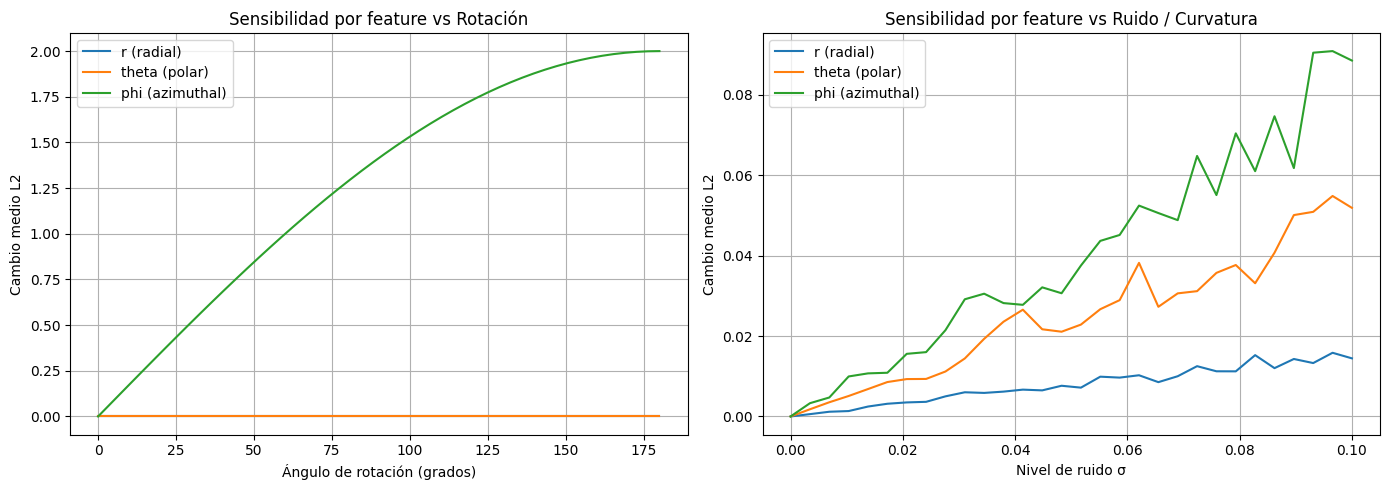

In [14]:
import matplotlib.pyplot as plt

angles = np.linspace(0, np.pi, 50)
r_rot, theta_rot, phi_rot = [], [], []

for a in angles:
    s_rot = rotate_z(streamline, a)
    com_rot = rotate_z(global_com[None, :], a)[0]
    feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
    r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
    r_rot.append(r_d)
    theta_rot.append(theta_d)
    phi_rot.append(phi_d)

# ---------- Preparar datos de ruido ----------
noise_levels = np.linspace(0, 0.1, 30)
r_noise, theta_noise, phi_noise = [], [], []

for n in noise_levels:
    s_noisy = add_local_noise(streamline, noise_std=n)
    feat_noisy = process_single_streamline(s_noisy, global_com, r_min, r_max)
    r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)
    r_noise.append(r_d)
    theta_noise.append(theta_d)
    phi_noise.append(phi_d)

# ---------- Plots combinados ----------
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# Rotación
axs[0].plot(np.degrees(angles), r_rot, label='r (radial)', color='tab:blue')
axs[0].plot(np.degrees(angles), theta_rot, label='theta (polar)', color='tab:orange')
axs[0].plot(np.degrees(angles), phi_rot, label='phi (azimuthal)', color='tab:green')
axs[0].set_xlabel("Ángulo de rotación (grados)")
axs[0].set_ylabel("Cambio medio L2")
axs[0].set_title("Sensibilidad por feature vs Rotación")
axs[0].legend()
axs[0].grid(True)

# Ruido / Curvatura
axs[1].plot(noise_levels, r_noise, label='r (radial)', color='tab:blue')
axs[1].plot(noise_levels, theta_noise, label='theta (polar)', color='tab:orange')
axs[1].plot(noise_levels, phi_noise, label='phi (azimuthal)', color='tab:green')
axs[1].set_xlabel("Nivel de ruido σ")
axs[1].set_ylabel("Cambio medio L2")
axs[1].set_title("Sensibilidad por feature vs Ruido / Curvatura")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

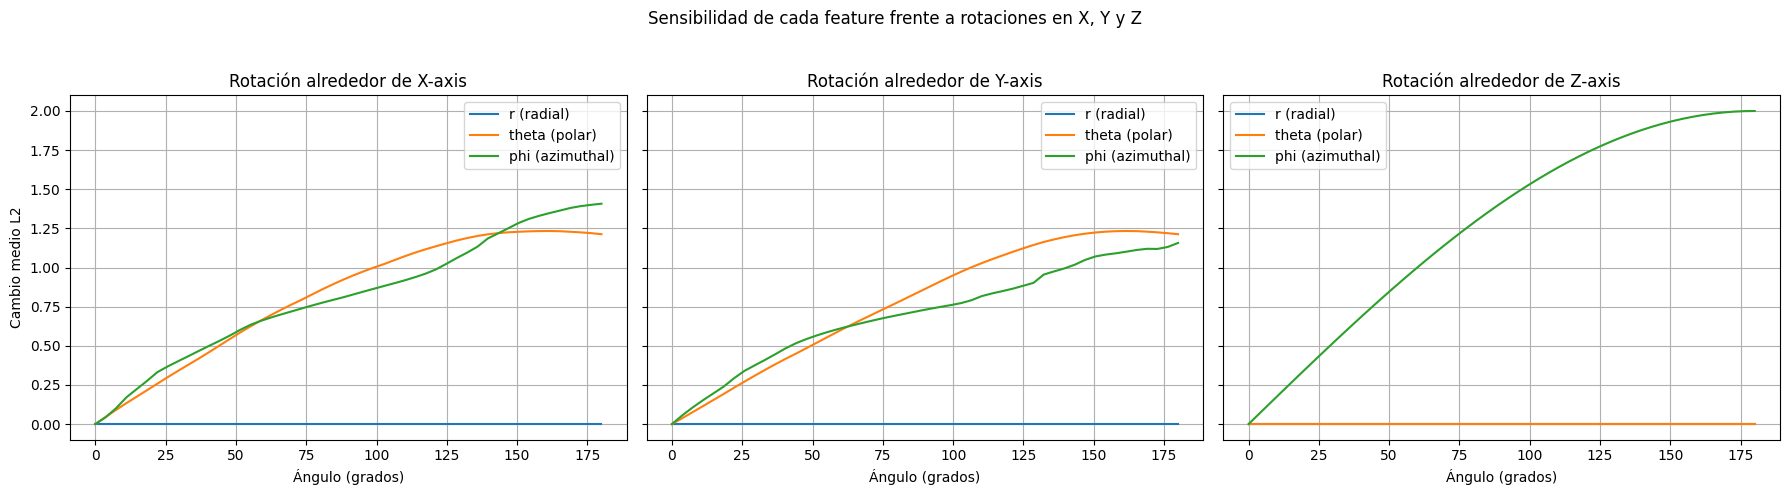

In [22]:
angles = np.linspace(0, np.pi, 50)  # 0 a 180°

# Diccionarios para almacenar resultados
results = {'X':[], 'Y':[], 'Z':[]}

for axis, rot_func in zip(['X','Y','Z'], [rotate_x, rotate_y, rotate_z]):
    r_vals, theta_vals, phi_vals = [], [], []
    for a in angles:
        s_rot = rot_func(streamline, a)
        com_rot = rot_func(global_com[None, :], a)[0]
        feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
        r_vals.append(r_d)
        theta_vals.append(theta_d)
        phi_vals.append(phi_d)
    results[axis] = (r_vals, theta_vals, phi_vals)

# ---------- Plot ----------
fig, axs = plt.subplots(1,3, figsize=(18,5), sharey=True)

for i, axis in enumerate(['X','Y','Z']):
    r_vals, theta_vals, phi_vals = results[axis]
    axs[i].plot(np.degrees(angles), r_vals, label='r (radial)', color='tab:blue')
    axs[i].plot(np.degrees(angles), theta_vals, label='theta (polar)', color='tab:orange')
    axs[i].plot(np.degrees(angles), phi_vals, label='phi (azimuthal)', color='tab:green')
    axs[i].set_xlabel("Ángulo (grados)")
    axs[i].set_title(f"Rotación alrededor de {axis}-axis")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Cambio medio L2")
    axs[i].legend()

plt.suptitle("Sensibilidad de cada feature frente a rotaciones en X, Y y Z")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

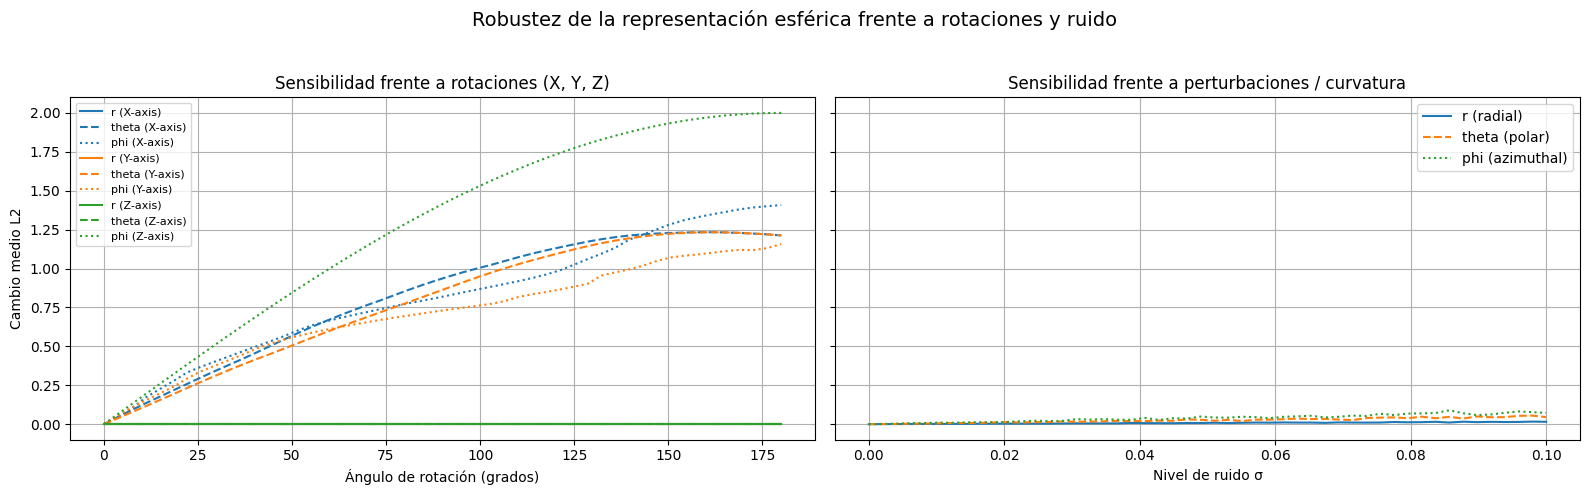

In [21]:
angles = np.linspace(0, np.pi, 50)
axes = {'X': rotate_x, 'Y': rotate_y, 'Z': rotate_z}
rotation_results = {}

for axis, rot_func in axes.items():
    r_vals, theta_vals, phi_vals = [], [], []
    for a in angles:
        s_rot = rot_func(streamline, a)
        com_rot = rot_func(global_com[None, :], a)[0]
        feat_rot = process_single_streamline(s_rot, com_rot, r_min, r_max)
        r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_rot)
        r_vals.append(r_d)
        theta_vals.append(theta_d)
        phi_vals.append(phi_d)
    rotation_results[axis] = (r_vals, theta_vals, phi_vals)

# ---------- Ruido / Curvatura ----------
noise_levels = np.linspace(0, 0.1, 50)
r_noise, theta_noise, phi_noise = [], [], []

for n in noise_levels:
    s_noisy = add_local_noise(streamline, noise_std=n)
    feat_noisy = process_single_streamline(s_noisy, global_com, r_min, r_max)
    r_d, theta_d, phi_d = feature_wise_l2(feat_orig, feat_noisy)
    r_noise.append(r_d)
    theta_noise.append(theta_d)
    phi_noise.append(phi_d)

# ---------- Plot final combinado ----------
fig, axs = plt.subplots(1,2, figsize=(16,5), sharey=True)

# Rotaciones
for axis, color in zip(['X','Y','Z'], ['tab:blue','tab:orange','tab:green']):
    r_vals, theta_vals, phi_vals = rotation_results[axis]
    axs[0].plot(np.degrees(angles), r_vals, label=f'r ({axis}-axis)', color=color, linestyle='-')
    axs[0].plot(np.degrees(angles), theta_vals, label=f'theta ({axis}-axis)', color=color, linestyle='--')
    axs[0].plot(np.degrees(angles), phi_vals, label=f'phi ({axis}-axis)', color=color, linestyle=':')
axs[0].set_xlabel("Ángulo de rotación (grados)")
axs[0].set_ylabel("Cambio medio L2")
axs[0].set_title("Sensibilidad frente a rotaciones (X, Y, Z)")
axs[0].grid(True)
axs[0].legend(fontsize=8)

# Ruido / Curvatura
axs[1].plot(noise_levels, r_noise, label='r (radial)', color='tab:blue', linestyle='-')
axs[1].plot(noise_levels, theta_noise, label='theta (polar)', color='tab:orange', linestyle='--')
axs[1].plot(noise_levels, phi_noise, label='phi (azimuthal)', color='tab:green', linestyle=':')
axs[1].set_xlabel("Nivel de ruido σ")
axs[1].set_title("Sensibilidad frente a perturbaciones / curvatura")
axs[1].grid(True)
axs[1].legend(fontsize=10)

plt.suptitle("Robustez de la representación esférica frente a rotaciones y ruido", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()